### Imports

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, RBF, RationalQuadratic

### Loading the files

In [3]:
X = np.load("initial_inputs.npy")
y = np.load("initial_outputs.npy")

### Exploring the data

In [4]:
# combining inputs and outputs into one dataFrame
df = pd.DataFrame(X, columns=["x1", "x2"])
df["y"] = y

In [5]:
df

,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


In [6]:
df.describe()

,x1,x2,y
count,10.000000,10.000000,1.000000e+01
mean,0.548817,0.539519,-3.606063e-04
std,0.259160,0.296007,1.140337e-03
min,0.082507,0.078723,-3.606063e-03
25%,0.342162,0.299421,-1.566820e-91
50%,0.612222,0.631890,6.793724e-80
75%,0.719122,0.755469,7.903833e-47
max,0.883890,0.879898,7.710875e-16


In [7]:
# printing the maximum value so far
df.loc[df["y"].idxmax()]

x1    7.310236e-01
x2    7.329999e-01
y     7.710875e-16
Name: 2, dtype: float64

### Visualising the data

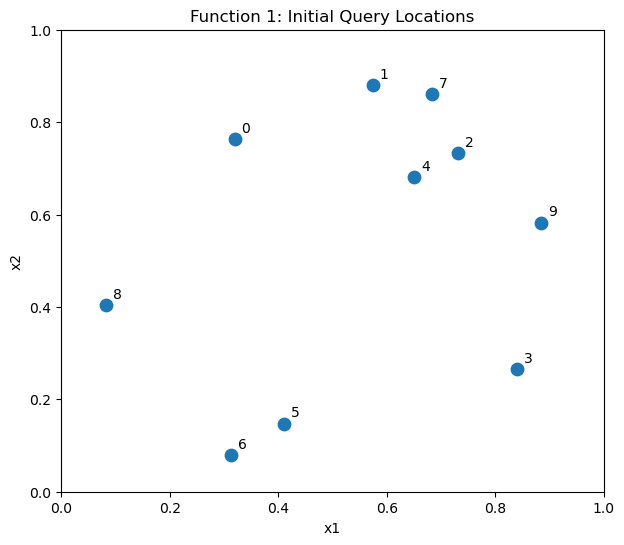

In [8]:
plt.figure(figsize=(7, 6))

plt.scatter(df["x1"], df["x2"], s=80)

for i, row in df.iterrows():
    plt.annotate(
        str(i),
        (row["x1"], row["x2"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Function 1: Initial Query Locations")
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.show()

### Bayesian optimisation - Gaussian Process

In [9]:
kernel = ConstantKernel(1.0) * Matern(
    length_scale=[0.2, 0.2],
    nu=2.5
)

In [10]:
gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

In [11]:
gp.fit(X, y)

,kernel,"1**2 * Matern... 0.2], nu=2.5)"
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,10
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,42
,kernel__k1,1**2
,kernel__k2,"Matern(length... 0.2], nu=2.5)"
,kernel__k1__constant_value,1.0


In [12]:
print(gp.kernel_)

1.02**2 * Matern(length_scale=[0.0167, 1.81e+03], nu=2.5)


#### Using a grid to evaluate the GP

In [13]:
# creating a grid of possible x1 and x2 values
x1_grid = np.linspace(0, 1, 100)
x2_grid = np.linspace(0, 1, 100)

In [14]:
xx1, xx2 = np.meshgrid(x1_grid, x2_grid)

In [15]:
grid_points = np.column_stack([
    xx1.ravel(),
    xx2.ravel()
])

In [16]:
# GP predictions
mean, std = gp.predict(grid_points, return_std=True)

#### Visually inspecting uncertainty

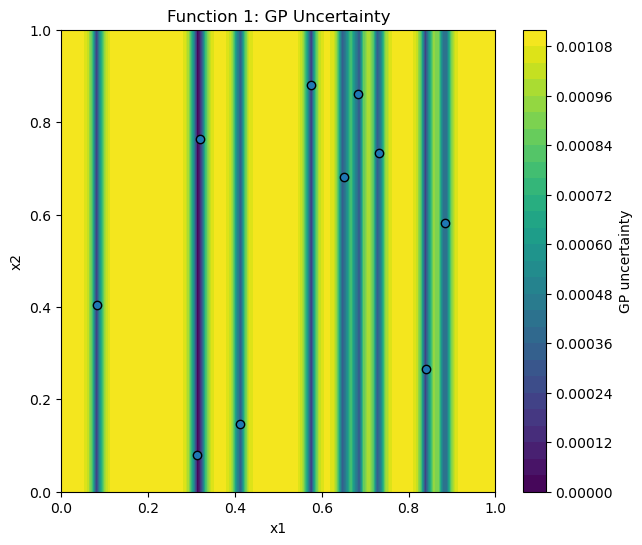

In [17]:
plt.figure(figsize=(7, 6))

plt.contourf(
    xx1,
    xx2,
    std.reshape(xx1.shape),
    levels=30
)

plt.colorbar(label="GP uncertainty")

plt.scatter(
    df["x1"],
    df["x2"],
    edgecolor="black"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Function 1: GP Uncertainty")

plt.show()

### UCB

In [18]:
beta = 1.96

ucb = mean + beta * std

best_index = np.argmax(ucb)
suggested_point = grid_points[best_index]

In [19]:
print("Suggested query:")
print(f"x1 = {suggested_point[0]:.6f}")
print(f"x2 = {suggested_point[1]:.6f}")
print(f"UCB = {ucb[best_index]:.6f}")

Suggested query:
x1 = 0.707071
x2 = 0.000000
UCB = 0.001897


In [20]:
best_index = np.argmax(ucb)

print(f"Predicted mean: {mean[best_index]:.8f}")
print(f"Predicted std:  {std[best_index]:.8f}")
print(f"UCB:            {ucb[best_index]:.8f}")

Predicted mean: -0.00004390
Predicted std:  0.00099015
UCB:            0.00189679


In [21]:
beta_values = [0.5, 1.0, 1.96, 3.0, 5.0]

for beta in beta_values:
    ucb_beta = mean + beta * std
    idx = np.argmax(ucb_beta)
    point = grid_points[idx]

    print(
        f"β={beta:>4}: "
        f"x1={point[0]:.6f}, "
        f"x2={point[1]:.6f}, "
        f"mean={mean[idx]:.6f}, "
        f"std={std[idx]:.6f}"
    )

β= 0.5: x1=0.696970, x2=0.909091, mean=0.000076, std=0.000837
β= 1.0: x1=0.707071, x2=0.919192, mean=-0.000044, std=0.000990
β=1.96: x1=0.707071, x2=0.000000, mean=-0.000044, std=0.000990
β= 3.0: x1=0.373737, x2=0.191919, mean=-0.000318, std=0.001094
β= 5.0: x1=0.363636, x2=0.000000, mean=-0.000332, std=0.001097


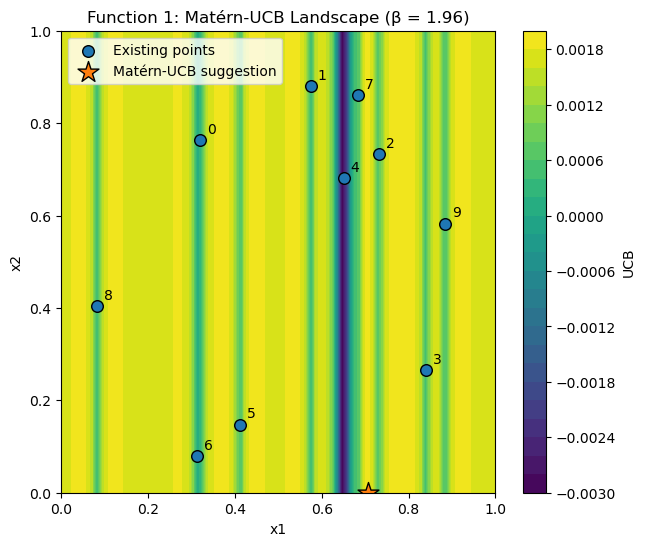

In [29]:
plt.figure(figsize=(7, 6))

# Plot the Matérn UCB landscape
plt.contourf(
    xx1,
    xx2,
    ucb.reshape(xx1.shape),
    levels=30
)

plt.colorbar(label="UCB")

# Plot the 10 existing observations
plt.scatter(
    df["x1"],
    df["x2"],
    edgecolor="black",
    s=70,
    label="Existing points"
)

# Plot the Matérn-UCB recommendation
plt.scatter(
    suggested_point[0],
    suggested_point[1],
    marker="*",
    s=250,
    edgecolor="black",
    label="Matérn-UCB suggestion"
)

# Label the existing observations 0–9
for i, row in df.iterrows():
    plt.annotate(
        str(i),
        (row["x1"], row["x2"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("x1")
plt.ylabel("x2")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("Function 1: Matérn-UCB Landscape (β = 1.96)")
plt.legend()
plt.show()

The Matérn GP seems to treat x2 as having very little influence on the predicted score, with the model's predictions changing mainly as x1 changes.

### Using an RBF GP

In [24]:
kernel_rbf = RBF(length_scale=0.1)

gp_rbf = GaussianProcessRegressor(
    kernel=kernel_rbf,
    normalize_y=True,
    optimizer=None
)

gp_rbf.fit(X, y)

,kernel,RBF(length_scale=0.1)
,alpha,1e-10
,optimizer,None
,n_restarts_optimizer,0
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__length_scale,0.1
,kernel__length_scale_bounds,"(1e-05, ...)"


In [25]:
print(gp_rbf.kernel_)

RBF(length_scale=0.1)


In [26]:
mean_rbf, std_rbf = gp_rbf.predict(
    grid_points,
    return_std=True
)

In [27]:
beta = 1.96

ucb_rbf = mean_rbf + beta * std_rbf

best_index_rbf = np.argmax(ucb_rbf)
suggested_point_rbf = grid_points[best_index_rbf]

print("RBF suggested query:")
print(f"x1 = {suggested_point_rbf[0]:.6f}")
print(f"x2 = {suggested_point_rbf[1]:.6f}")
print(f"Predicted mean = {mean_rbf[best_index_rbf]:.8f}")
print(f"Predicted std  = {std_rbf[best_index_rbf]:.8f}")
print(f"UCB            = {ucb_rbf[best_index_rbf]:.8f}")

RBF suggested query:
x1 = 0.838384
x2 = 0.767677
Predicted mean = 0.00110509
Predicted std  = 0.00085895
UCB            = 0.00278863


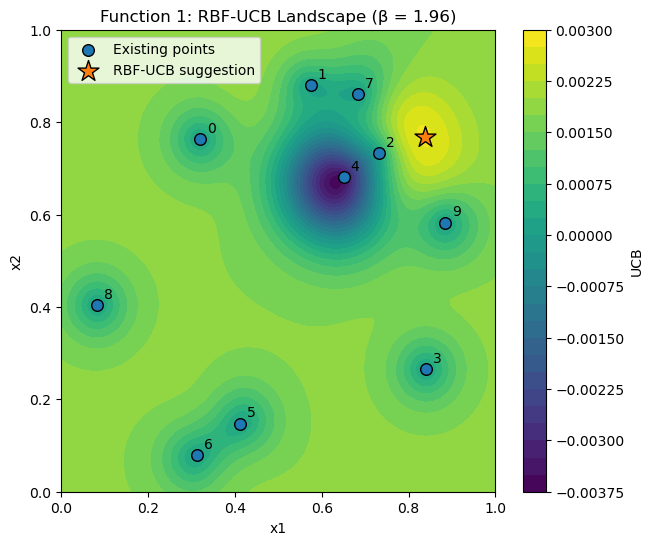

In [31]:
plt.figure(figsize=(7, 6))

plt.contourf(
    xx1,
    xx2,
    ucb_rbf.reshape(xx1.shape),
    levels=30
)

plt.colorbar(label="UCB")

# Existing observations
plt.scatter(
    df["x1"],
    df["x2"],
    edgecolor="black",
    s=70,
    label="Existing points"
)

# RBF recommendation
plt.scatter(
    suggested_point_rbf[0],
    suggested_point_rbf[1],
    marker="*",
    s=250,
    edgecolor="black",
    label="RBF-UCB suggestion"
)

for i, row in df.iterrows():
    plt.annotate(
        str(i),
        (row["x1"], row["x2"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("x1")
plt.ylabel("x2")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("Function 1: RBF-UCB Landscape (β = 1.96)")
plt.legend()
plt.show()

### My observations so far

Point 2 has the highest observed output, but nearby observations do not show consistently high outputs. The GP models also produced quite different recommendations depending on the kernel and exploration parameter. Because the initial data are sparse, I therefore don't know if I want to rely entirely on the surrogate model in this first iteration. Instead, I think I will prioritise exploration and manually query an under-sampled region near the centre of the search space.

In [32]:
df.sort_values("y", ascending=False) # to see which points have the best observed values

,x1,x2,y
2,0.731024,0.733000,7.710875e-16
7,0.683418,0.861057,2.535001e-40
1,0.574329,0.879898,1.033078e-46
9,0.883890,0.582254,6.229856e-48
0,0.319404,0.762959,1.322677e-79
8,0.082507,0.403488,3.606771e-81
3,0.840353,0.264732,3.341771e-124
6,0.312691,0.078723,-2.089093e-91
5,0.410437,0.147554,-2.159249e-54
4,0.650114,0.681526,-3.606063e-03


I still want to try one more surrogate model before I make an informed decision

### GP using RationalQuadratic

In [55]:
kernel_rq = 1.0 * RationalQuadratic(length_scale=0.1, alpha = 1.0)

gp_rq = GaussianProcessRegressor(
    kernel=kernel_rq,
    normalize_y=True,
    optimizer=None
)

gp_rq.fit(X, y)

,kernel,1**2 * Ration...gth_scale=0.1)
,alpha,1e-10
,optimizer,None
,n_restarts_optimizer,0
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,RationalQuadr...gth_scale=0.1)
,kernel__k1__constant_value,1.0


In [56]:
print(gp_rq.kernel_)

1**2 * RationalQuadratic(alpha=1, length_scale=0.1)


In [57]:
mean_rq, std_rq = gp_rq.predict(
    grid_points,
    return_std=True
)

beta = 1.96
ucb_rq = mean_rq + beta * std_rq

best_index_rq = np.argmax(ucb_rq)
suggested_point_rq = grid_points[best_index_rq]

In [58]:
print("Rational Quadratic suggested query:")
print(f"x1 = {suggested_point_rq[0]:.6f}")
print(f"x2 = {suggested_point_rq[1]:.6f}")
print(f"Predicted mean = {mean_rq[best_index_rq]:.8f}")
print(f"Predicted std  = {std_rq[best_index_rq]:.8f}")
print(f"UCB            = {ucb_rq[best_index_rq]:.8f}")

Rational Quadratic suggested query:
x1 = 0.838384
x2 = 0.787879
Predicted mean = 0.00059231
Predicted std  = 0.00084278
UCB            = 0.00224416


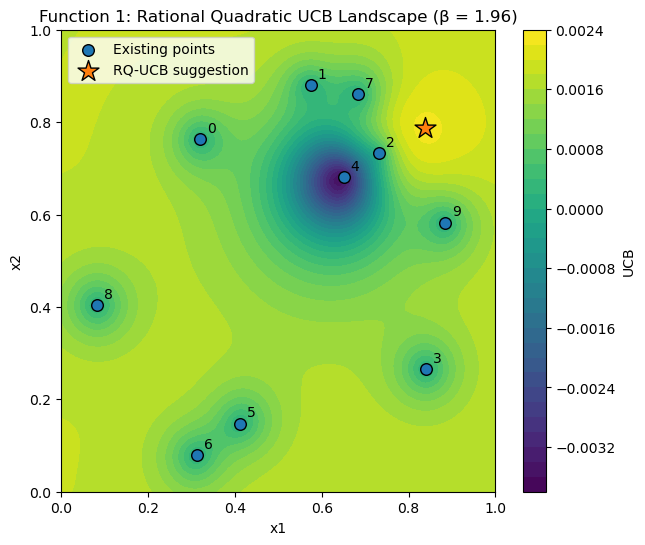

In [59]:
plt.figure(figsize=(7, 6))

plt.contourf(
    xx1,
    xx2,
    ucb_rq.reshape(xx1.shape),
    levels=30
)

plt.colorbar(label="UCB")

# Existing observations
plt.scatter(
    df["x1"],
    df["x2"],
    edgecolor="black",
    s=70,
    label="Existing points"
)

# RQ-UCB suggested point
plt.scatter(
    suggested_point_rq[0],
    suggested_point_rq[1],
    marker="*",
    s=250,
    edgecolor="black",
    label="RQ-UCB suggestion"
)

# Point numbers
for i, row in df.iterrows():
    plt.annotate(
        str(i),
        (row["x1"], row["x2"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("x1")
plt.ylabel("x2")
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.title("Function 1: Rational Quadratic UCB Landscape (β = 1.96)")
plt.legend()

plt.show()

In [60]:
print("Suggested point:", suggested_point_rq)
print("Predicted mean:", mean_rq[best_index_rq])
print("Uncertainty:", std_rq[best_index_rq])
print("UCB:", ucb_rq[best_index_rq])
print("Fitted kernel:", gp_rq.kernel_)

Suggested point: [0.83838384 0.78787879]
Predicted mean: 0.0005923058448988924
Uncertainty: 0.0008427837019857381
UCB: 0.002244161900790939
Fitted kernel: 1**2 * RationalQuadratic(alpha=1, length_scale=0.1)


### Plotting all suggested points by all 3 models

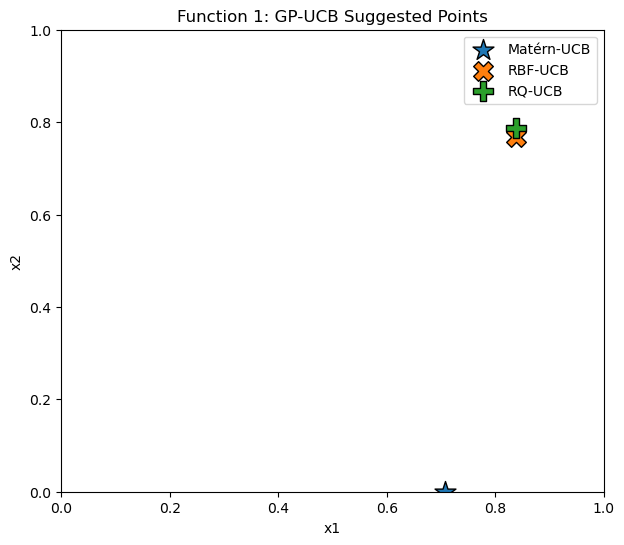

In [62]:
plt.figure(figsize=(7, 6))

# Matérn suggestion
plt.scatter(
    0.707071, 0.000000,
    marker="*",
    s=250,
    edgecolor="black",
    label="Matérn-UCB"
)

# RBF suggestion
plt.scatter(
    0.838384, 0.767677,
    marker="X",
    s=200,
    edgecolor="black",
    label="RBF-UCB"
)

# Rational Quadratic suggestion
plt.scatter(
    0.838384, 0.787879,
    marker="P",
    s=200,
    edgecolor="black",
    label="RQ-UCB"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.title("Function 1: GP-UCB Suggested Points")
plt.legend()

plt.show()

### Observations now

I now have three GP models, and two of them, RBF and Rational Quadratic, suggest points in almost the same region. This makes me more inclined to query that area for my first query, although I recognise that RBF and RQ are relatively similar kernels, so their agreement is not completely independent evidence. 

Querying this region still gives me a useful exploration–exploitation trade-off: if the result is promising, it provides evidence that this region is worth investigating further. If the result is poor, it reduces my confidence in this region and would encourage me to prioritise exploration of less-sampled areas in the next round.

### My decision for my first query

After analysing the initial data and comparing the GP models, I decided to select `0.838384-0.787879` from the two very similar RBF and Rational Quadratic suggestions. Both models highlighted approximately the same region, which suggests that it may be worth investigating. 

This choice provides a balance between exploitation and exploration: it exploits the information from the current best-performing region while still exploring a new, unobserved point nearby.

I recognise that the initial data is limited and the model predictions are therefore uncertain, but based on the evidence currently available, this represents the most informed choice I can make for my first query.